**Carson Plett | 501042248
| ELE888 Lab 1**

In [34]:
# Get data from url
import pandas as pd

url = 'https://raw.githubusercontent.com/yoga-suhas-km/Intelligent_systems/main/marks_dataset.csv'
data = pd.read_csv(url)
print(data)

    Midterm mark  Final mark
0           32.5        31.7
1           53.4        68.8
2           61.5        62.6
3           47.5        71.5
4           59.8        87.2
..           ...         ...
95          50.0        81.5
96          49.2        72.1
97          50.0        85.2
98          48.1        66.2
99          25.1        53.5

[100 rows x 2 columns]


In [35]:
# Calculate mean and standard deviation
mean_values = data.mean()
std_dev_values = data.std()
print(f"Mean values:\n{mean_values}\n")
print(f"Standard deviation values:\n{std_dev_values}")

Mean values:
Midterm mark    48.959
Final mark      72.735
dtype: float64

Standard deviation values:
Midterm mark     9.746495
Final mark      16.658249
dtype: float64


In [36]:
# Standardize the data
data_standardized = (data - mean_values) / std_dev_values
print(data_standardized)

    Midterm mark  Final mark
0      -1.688710   -2.463344
1       0.455651   -0.236219
2       1.286719   -0.608407
3      -0.149695   -0.074137
4       1.112297    0.868339
..           ...         ...
95      0.106808    0.526166
96      0.024727   -0.038119
97      0.106808    0.748278
98     -0.088134   -0.392298
99     -2.447957   -1.154683

[100 rows x 2 columns]


To determine the standardized data, the mean of the data was subtracted from every data point. This difference was then divided by the standard deviation of the data as portrayed by the code above.

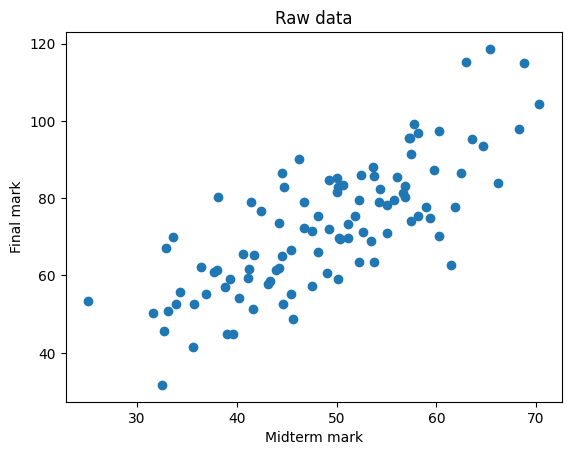

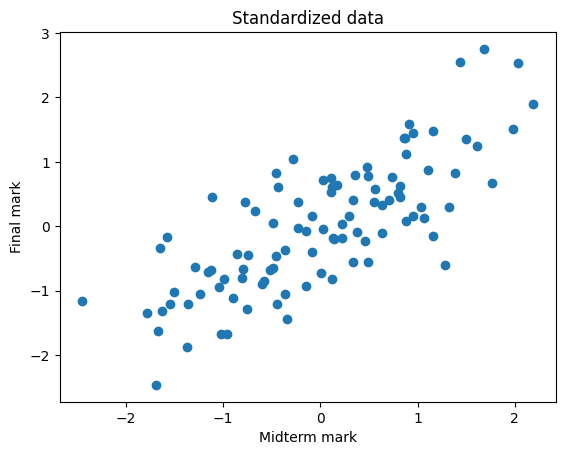

In [37]:
# Plot the data (both raw and standardized)
import matplotlib.pyplot as plt

x = data['Midterm mark'].values
y = data['Final mark'].values

plt.scatter(x, y)
plt.xlabel('Midterm mark')
plt.ylabel('Final mark')
plt.title('Raw data')
plt.show()

std_x = data_standardized['Midterm mark'].values
std_y = data_standardized['Final mark'].values

plt.scatter(std_x, std_y)
plt.xlabel('Midterm mark')
plt.ylabel('Final mark')
plt.title('Standardized data')
plt.show()

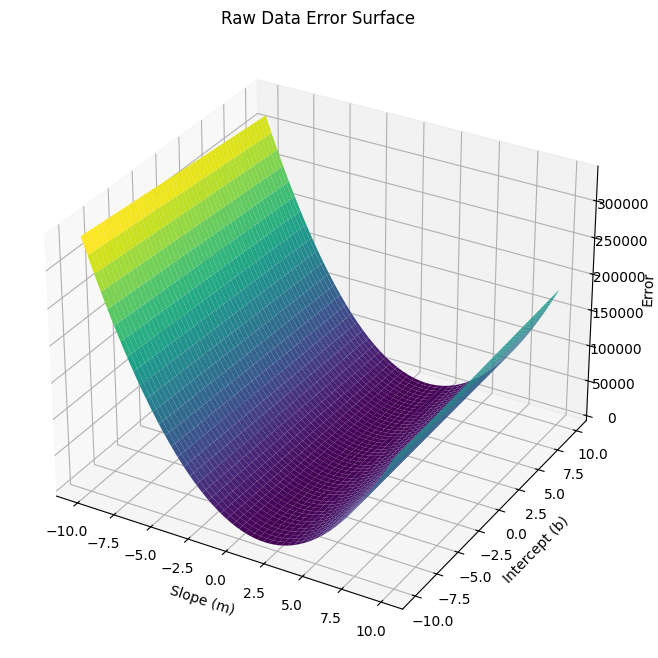

In [38]:
# Plot the error function shape for raw data
import matplotlib.pyplot as plt
import numpy as np

x = data['Midterm mark'].values
y = data['Final mark'].values

m_values = np.arange(-10, 10, 0.1)
b_values = np.arange(-10, 10, 0.1)

m, b = np.meshgrid(m_values, b_values)

N = len(x)
errors = np.zeros_like(m)
for i in range(N):
  errors += ((y[i]-(m*x[i]+b))**2)
errors /= N

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(m, b, errors, cmap='viridis', edgecolor='none')
ax.set_xlabel('Slope (m)')
ax.set_ylabel('Intercept (b)')
ax.set_zlabel('Error')
ax.set_title('Raw Data Error Surface')
plt.show()

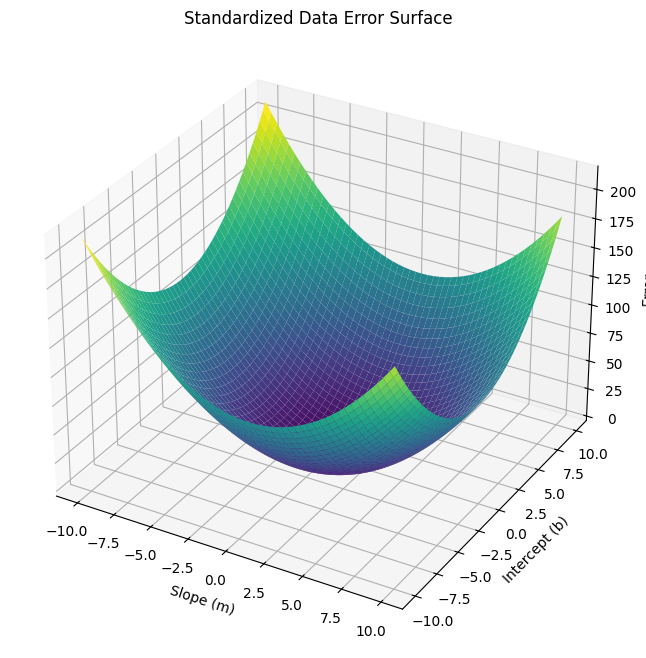

In [39]:
# Plot the error function for standardized data
import matplotlib.pyplot as plt
import numpy as np

std_x = data_standardized['Midterm mark'].values
std_y = data_standardized['Final mark'].values

m_values = np.arange(-10, 10, 0.1)
b_values = np.arange(-10, 10, 0.1)

m, b = np.meshgrid(m_values, b_values)

N = len(std_x)
errors = np.zeros_like(m)
for i in range(N):
  errors += ((std_y[i]-(m*std_x[i]+b))**2)
errors /= N

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(m, b, errors, cmap='viridis', edgecolor='none')
ax.set_xlabel('Slope (m)')
ax.set_ylabel('Intercept (b)')
ax.set_zlabel('Error')
ax.set_title('Standardized Data Error Surface')
plt.show()

Functions calculating partial derivatives, new m and b parameters, and error provided below.

In [40]:
# Function calculating partial derivatives
def calc_derivative(m, b, x, y):
  N = len(x)
  m_term = 0
  b_term = 0
  for i in range(N):
    error_term = (y[i]-(m*x[i]+b))
    m_term += -x[i]*error_term
    b_term += -error_term
  dE_dm = (2*m_term)/N
  dE_db = (2*b_term)/N
  return dE_dm, dE_db

# Function calculating new m and b parameters
def update_m_b(m_old, b_old, a, x, y):
  dE_dm, dE_db = calc_derivative(m_old, b_old, x, y)
  m_new = m_old - a*dE_dm
  b_new = b_old - a*dE_db
  return m_new, b_new

# Function calculating error
def calculate_error(m, b, x, y):
  N = len(x)
  sum_error = 0
  for i in range(N):
    sum_error += ((y[i] - (m * x[i] + b)) ** 2) / N
  return sum_error

**Raw data and 100 updates to m and b below**


m and b after 100 iterations: m = 1.4785727560143909, b = 0.04490536397288713



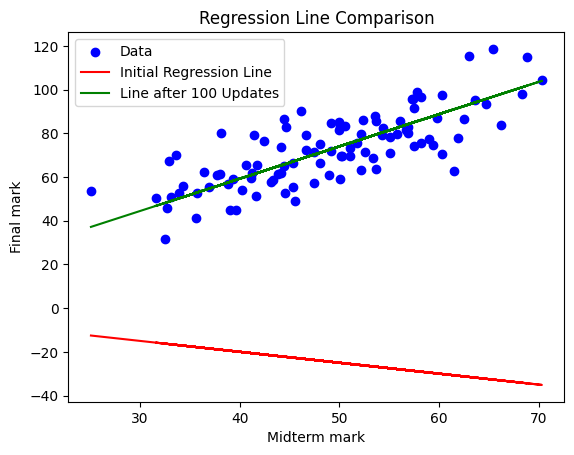

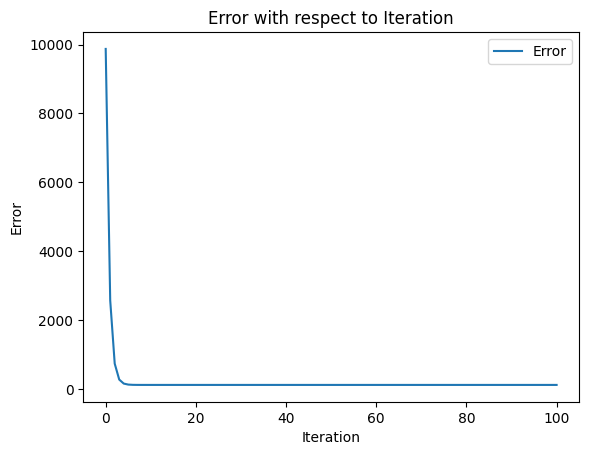

In [ ]:
# RAW DATA and 100 ITERATIONS
# Show initial regression line against raw data
import matplotlib.pyplot as plt

x = data['Midterm mark'].values
y = data['Final mark'].values

# TOGGLE LEARNING RATE PARAMETER BELOW a = 0.1 vs. a = 0.0001
a = 0.0001
m = -0.5
b = 0
line_y = m * x + b

plt.scatter(x, y, label='Data', color='blue')
plt.plot(x, line_y, label='Initial Regression Line', color='red')
plt.xlabel('Midterm mark')
plt.ylabel('Final mark')

# Update m and b 100 times using raw data
for i in range(100):
  m, b = update_m_b(m, b, a, x, y)
print(f"\nm and b after 100 iterations: m = {m}, b = {b}\n")

# Plot regression line after 100 updates to m and b using raw data
line_y100 = m * x + b

plt.plot(x, line_y100, label='Line after 100 Updates', color='green')
plt.title('Regression Line Comparison')
plt.legend()
plt.show()

# Plot error versus iteration number for raw data and 100 iterations
m = -0.5
b = 0
errors = []
errors.append(calculate_error(m, b, x, y))

for i in range(100):
  m, b = update_m_b(m, b, a, x, y)
  errors.append(calculate_error(m, b, x, y))

plt.plot(range(101), errors, label='Error')
plt.xlabel('Iteration')
plt.ylabel('Error')
plt.title('Error with respect to Iteration')
plt.legend()
plt.show()

As can be seen from the above figures, after 100 updates to m and b, the line is already representing the data well. From the graph of error with respect to iteration, the line appears to have represented the data well after only a few updates. Evidently, the learning rate of 0.0001 is working well with the non-standardized data.

By contrast, when the learning rate was updated to 0.1, the regression line after 100 updates was far worse than the original regression line.

**Raw Data and 2000 updates to m and b below**


m and b after 2000 iterations: m = 1.4763433036607632, b = 0.15833790708442705



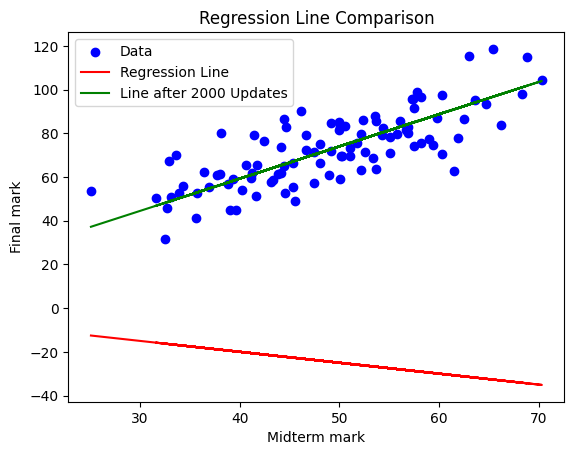

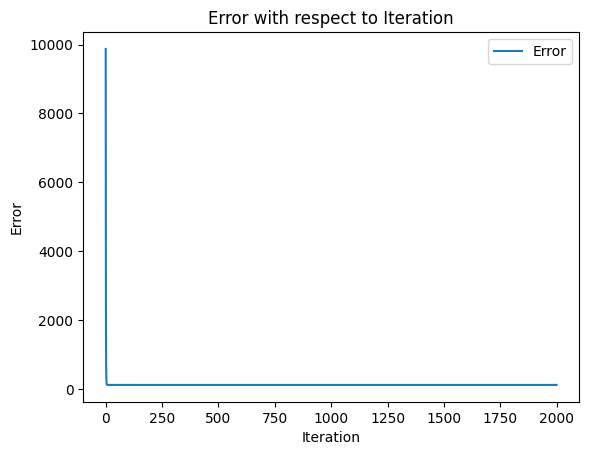

In [ ]:
# RAW DATA and 2000 ITERATIONS
# Show initial regression line against raw data
import matplotlib.pyplot as plt

x = data['Midterm mark'].values
y = data['Final mark'].values

# TOGGLE LEARNING RATE PARAMETER BELOW a = 0.1 vs. a = 0.0001
a = 0.0001
m = -0.5
b = 0
line_y = m * x + b

plt.scatter(x, y, label='Data', color='blue')
plt.plot(x, line_y, label='Regression Line', color='red')
plt.xlabel('Midterm mark')
plt.ylabel('Final mark')
plt.title('Regression Line Comparison')

# Update m and b 2000 times using raw data
for i in range(2000):
  m, b = update_m_b(m, b, a, x, y)
print(f"\nm and b after 2000 iterations: m = {m}, b = {b}\n")

# Plot regression line after 2000 updates to m and b using raw data
line_y2000 = m * x + b

plt.plot(x, line_y2000, label='Line after 2000 Updates', color='green')
plt.legend()
plt.show()

# Plot error versus iteration number for raw data and 2000 iterations
m = -0.5
b = 0
errors = []
errors.append(calculate_error(m, b, x, y))

for i in range(2000):
  m, b = update_m_b(m, b, a, x, y)
  errors.append(calculate_error(m, b, x, y))

plt.plot(range(2001), errors, label='Error')
plt.xlabel('Iteration')
plt.ylabel('Error')
plt.title('Error with respect to Iteration')
plt.legend()
plt.show()

Nothing too exciting happened here. Since the data was already well represented after 100 updates, updating m and b an additional 1900 times provided a line that fits well, but not very differently, from that line attained after updating m and b only 100 times.

Also, in increasing the learning rate from 0.0001 to even 0.00045, the regression line suffered in its ability to model the non-standardized data. After 2000 iterations with the learning rate at 0.000425, the regression line looked similar to the model of the non-standardized data depicted by the regression line retrieved after 100 iterations of a learning rate of 0.1.

**Standardized Data and 100 updates to m and b below**


m and b after 100 iterations: m = -0.475030672874282, b = -2.603250948141068e-18



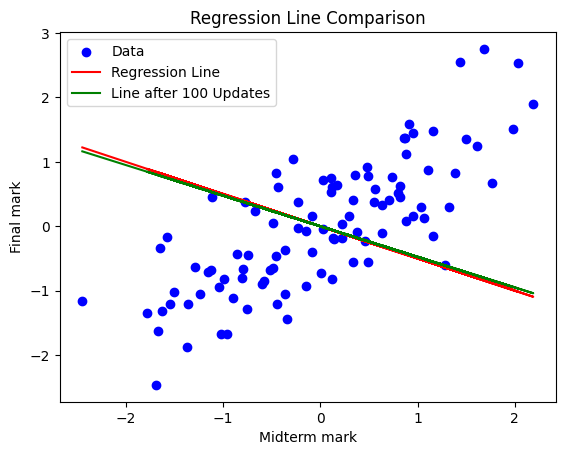

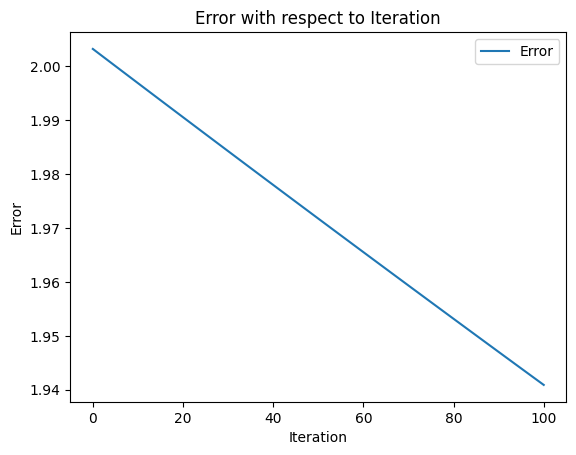

In [ ]:
# STANDARDIZED DATA and 100 ITERATIONS
# Show initial regression line against standardized data
import matplotlib.pyplot as plt

std_x = data_standardized['Midterm mark'].values
std_y = data_standardized['Final mark'].values

# TOGGLE LEARNING RATE PARAMETER BELOW a = 0.1 vs. a = 0.0001
a = 0.0001
m = -0.5
b = 0
line_y = m * std_x + b

plt.scatter(std_x, std_y, label='Data', color='blue')
plt.plot(std_x, line_y, label='Regression Line', color='red')
plt.xlabel('Midterm mark')
plt.ylabel('Final mark')
plt.title('Regression Line Comparison')

# Update m and b 100 times using raw data
for i in range(100):
  m, b = update_m_b(m, b, a, std_x, std_y)
print(f"\nm and b after 100 iterations: m = {m}, b = {b}\n")

# Plot regression line after 100 updates to m and b using raw data
line_y100 = m * std_x + b

plt.plot(std_x, line_y100, label='Line after 100 Updates', color='green')
plt.legend()
plt.show()

# Plot error versus iteration number for raw data and 100 iterations
m = -0.5
b = 0
errors = []
errors.append(calculate_error(m, b, std_x, std_y))

for i in range(100):
  m, b = update_m_b(m, b, a, std_x, std_y)
  errors.append(calculate_error(m, b, std_x, std_y))

plt.plot(range(101), errors, label='Error')
plt.xlabel('Iteration')
plt.title('Error with respect to Iteration')
plt.ylabel('Error')
plt.legend()
plt.show()

The same learning rate, of 0.0001, does not work well with the standardized data. Evidently this is a result of its 2D surface and the fact that improving the slope and intercept by this small amount every iteration is not significant enough to make an appreciable impact on the linear modelling of the data. If you increase the learning rate to 0.1, then the line after 100 iterations is approaching that which it should be. That is to say, with the standardized data, the learning rate of 0.1 works better than the learning rate of 0.0001.

**Standardized Data and 2000 updates to m and b below**


m and b after 2000 iterations: m = 0.7734781435681712, b = 2.7777780076121503e-16



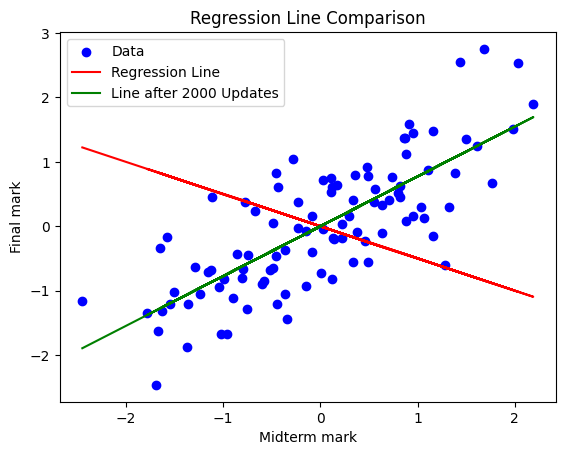

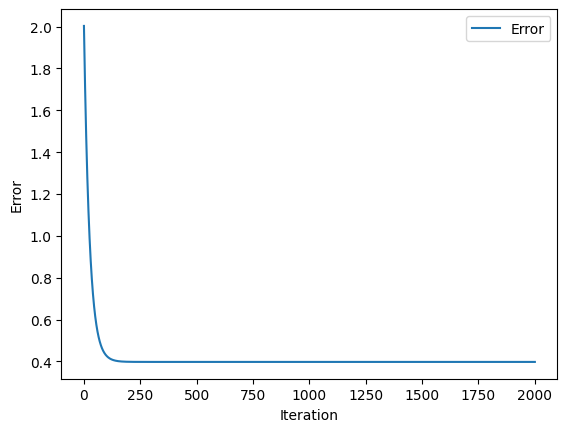

In [ ]:
# STANDARDIZED DATA and 2000 ITERATIONS
# Show initial regression line against standardized data
import matplotlib.pyplot as plt

std_x = data_standardized['Midterm mark'].values
std_y = data_standardized['Final mark'].values

# TOGGLE LEARNING RATE PARAMETER BELOW a = 0.1 vs. a = 0.0001
a = 0.01
m = -0.5
b = 0
line_y = m * std_x + b

plt.scatter(std_x, std_y, label='Data', color='blue')
plt.plot(std_x, line_y, label='Regression Line', color='red')
plt.xlabel('Midterm mark')
plt.ylabel('Final mark')
plt.title('Regression Line Comparison')

# Update m and b 2000 times using raw data
for i in range(2000):
  m, b = update_m_b(m, b, a, std_x, std_y)
print(f"\nm and b after 2000 iterations: m = {m}, b = {b}\n")

# Plot regression line after 2000 updates to m and b using raw data
line_y2000 = m * std_x + b

plt.plot(std_x, line_y2000, label='Line after 2000 Updates', color='green')
plt.legend()
plt.show()

# Plot error versus iteration number for raw data and 2000 iterations
m = -0.5
b = 0
errors = []
errors.append(calculate_error(m, b, std_x, std_y))

for i in range(2000):
  m, b = update_m_b(m, b, a, std_x, std_y)
  errors.append(calculate_error(m, b, std_x, std_y))

plt.plot(range(2001), errors, label='Error')
plt.xlabel('Iteration')
plt.ylabel('Error')
plt.legend()
plt.show()

With 2000 updates to m and b, the learning rate of 0.0001 still does not represent the standardized data well. With the learning rate of 0.1, however, just as with the trial of 100 updates, the line represents the standardized data well.

**Verifying results**

For the non-standardized model
	m = 1.321992317252377
	b = 8.01157813964086

For the standardized model
	m = 0.7734781435681741
	b = 1.9759457007989858e-16


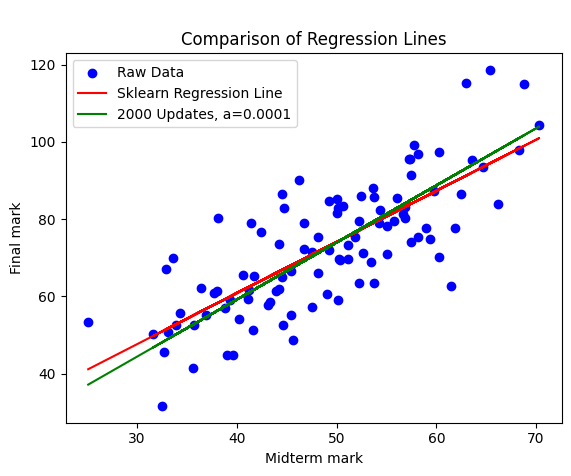

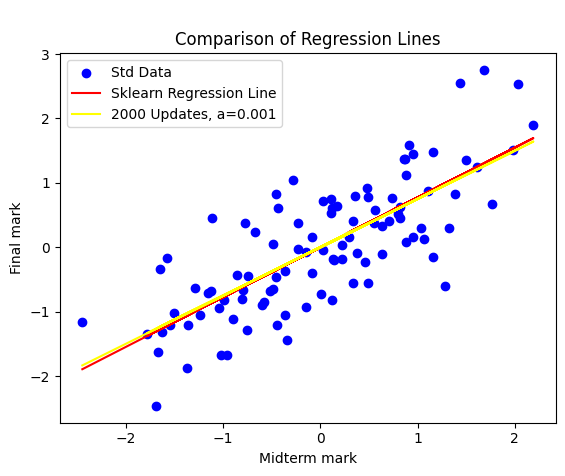

In [ ]:
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression

x = data['Midterm mark'].values.reshape(-1,1)
y = data['Final mark'].values

std_x = data_standardized['Midterm mark'].values.reshape(-1,1)
std_y = data_standardized['Final mark'].values

model = LinearRegression()
std_model = LinearRegression()

model.fit(x, y)
m = model.coef_[0]
b = model.intercept_

print(f"For the non-standardized model\n\tm = {m}\n\tb = {b}")

std_model.fit(std_x, std_y)
std_m = std_model.coef_[0]
std_b = std_model.intercept_

print(f"\nFor the standardized model\n\tm = {std_m}\n\tb = {std_b}")

# Graph comparison of Sklearn and Update Method
# For 2000 updates of m and b with non-standardized data
# m = 1.4763433036607632, b = 0.15833790708442705
line_y = m * x + b
m2000 = 1.4763433036607632
b2000 = 0.15833790708442705
y2000 = m2000 * x + b2000
plt.scatter(x, y, label='Raw Data', color='blue')
plt.plot(x, line_y, label='Sklearn Regression Line', color='red')
plt.plot(x, y2000, label='2000 Updates, a=0.0001', color='green')
plt.xlabel('Midterm mark')
plt.ylabel('Final mark')
plt.title('\nComparison of Regression Lines')
plt.legend()
plt.show()

# Graph comparison of Sklearn and Update Method
# For 2000 updates of m and b with non-standardized data
# m = 0.7492967966086642, b = 1.837496821366356e-16
line_y = std_m * std_x + std_b
std_m2000 = 0.7492967966086642
std_b2000 = 1.837496821366356e-16
std_y2000 = std_m2000 * std_x + std_b2000
plt.scatter(std_x, std_y, label='Std Data', color='blue')
plt.plot(std_x, line_y, label='Sklearn Regression Line', color='red')
plt.plot(std_x, std_y2000, label='2000 Updates, a=0.001', color='yellow')
plt.xlabel('Midterm mark')
plt.ylabel('Final mark')
plt.title('\nComparison of Regression Lines')
plt.legend()
plt.show()

The results confirm the findings gathered throughout the investigation.

In general, the Sklearn regression line achieved better results than the update parameters method especially when the learning rate of 0.0001 was maintained through the trial. When the learning rate was increased to 0.1 in the 2000 iteration trial, the results were fairly consistent.

For the raw, or non-standardized data, the results were fairly consistent throughout as the graphs above demonstrate.